array(['TypeII_PFT_bacteria', 'Type_III', 'TypeIII_controlToxin',
       'Type_II', 'Type_I', 'Type_IV'], dtype=object)

/var/folders/w7/0t5kmt6s76n4ryth253rlrx00000gn/T/ipykernel_9553/3443559998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Sequence Length', data=merged_df, palette="Set3")


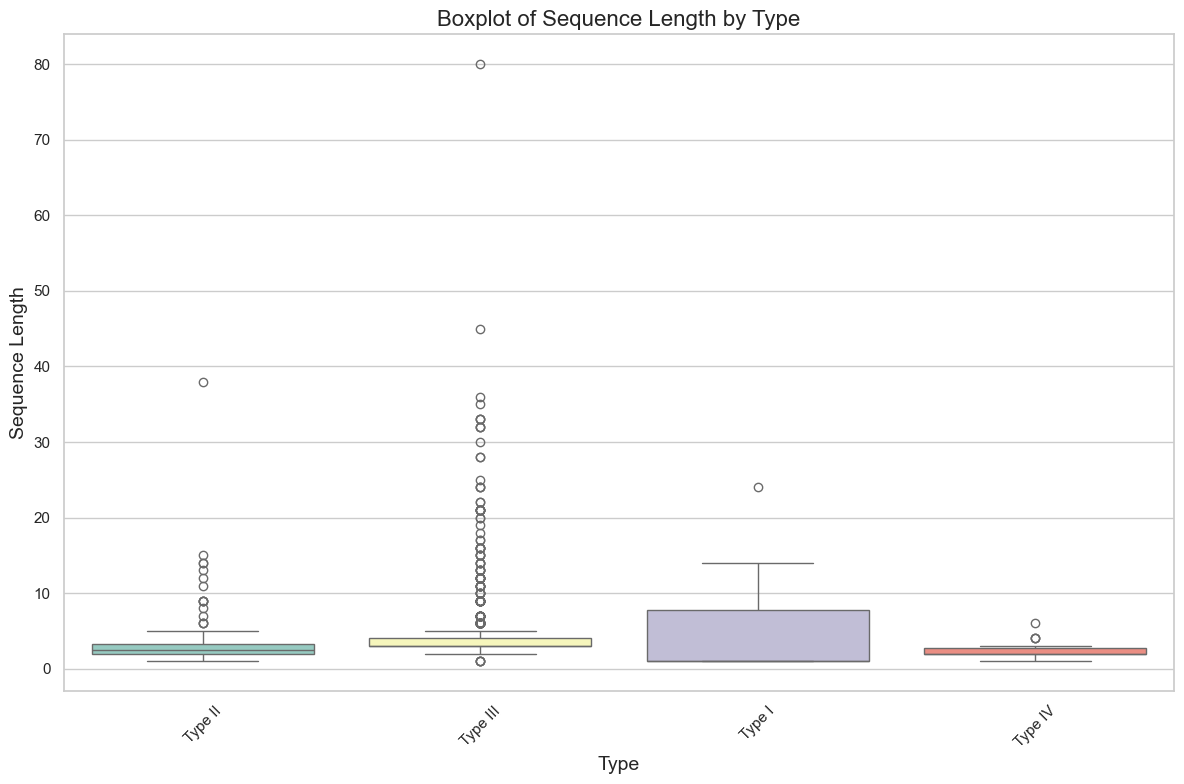

Columns before processing: ['ID', 'species', 'type', 'target']
CSV processing successful.
Fasta DataFrame created with 787 records.
Merged DataFrame has 791 records.
Data processing completed successfully.


/var/folders/w7/0t5kmt6s76n4ryth253rlrx00000gn/T/ipykernel_9553/1499328854.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


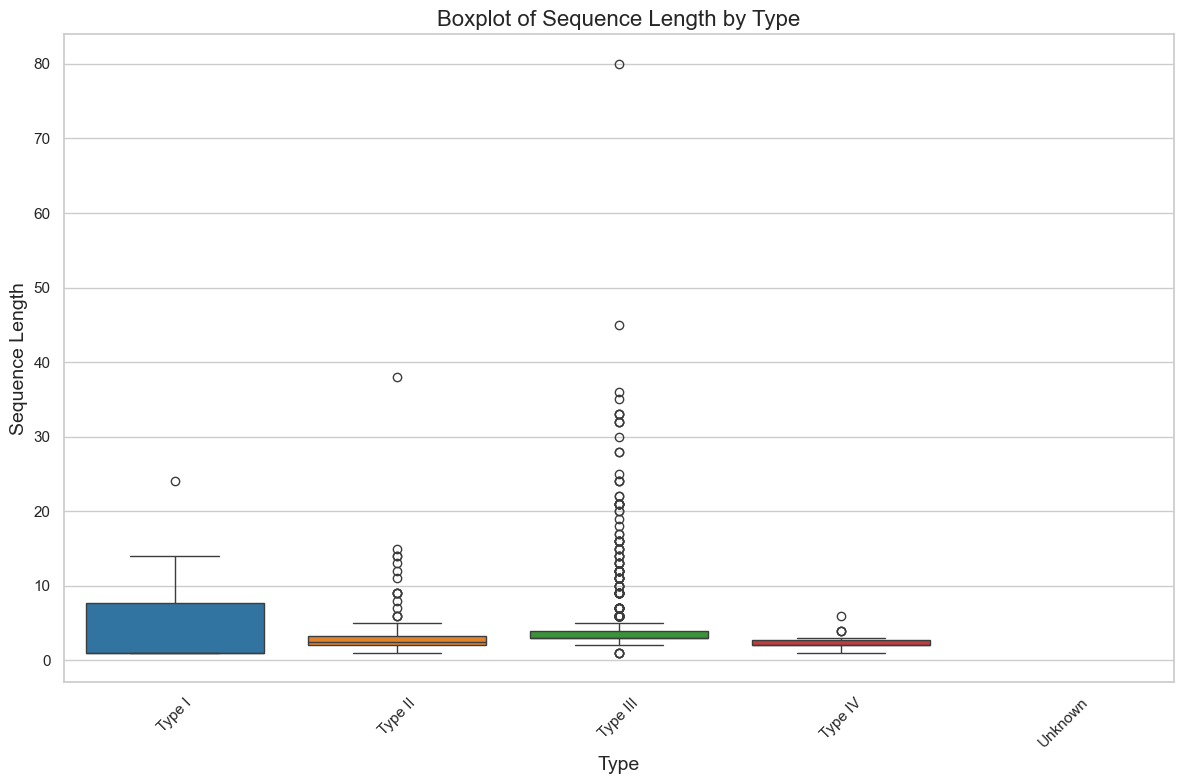

Unique Target categories:
['Non-vertebrate' 'Vertebrate']


/var/folders/w7/0t5kmt6s76n4ryth253rlrx00000gn/T/ipykernel_9553/1499328854.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


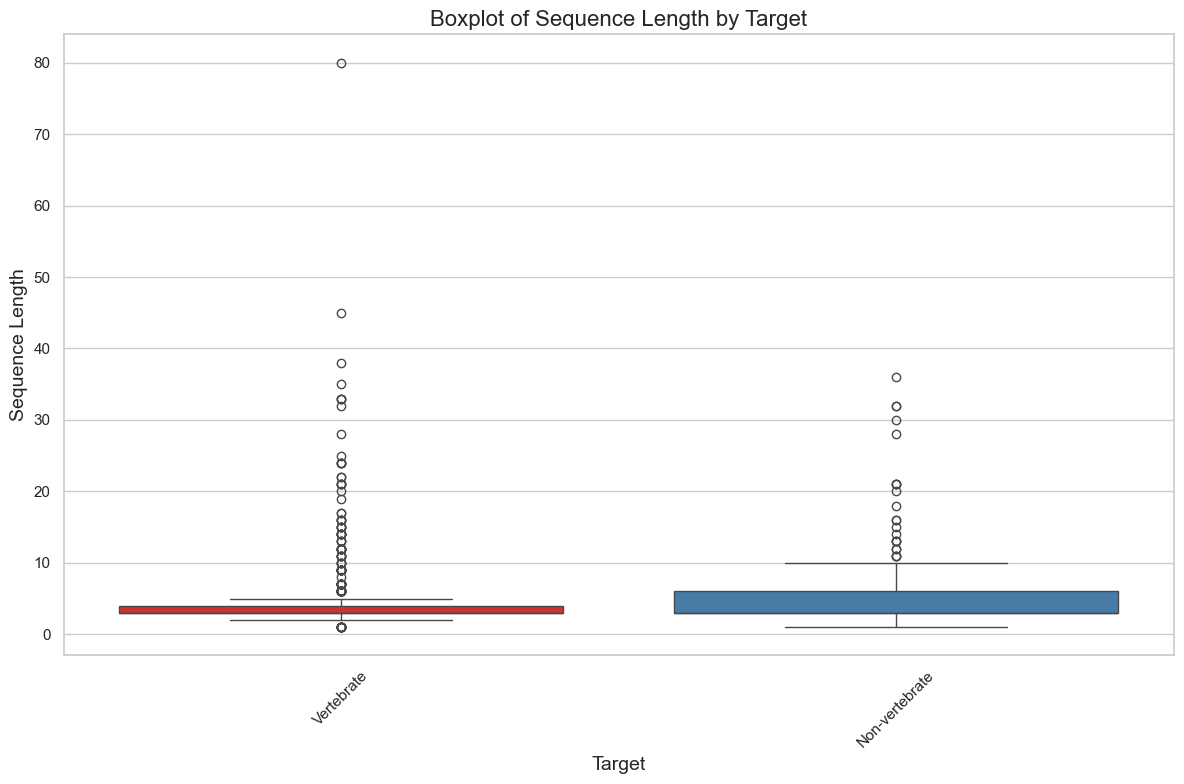

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
import statsmodels.api as sm
import statsmodels.formula.api as smf

# -------------------------------
# 1. Data Processing with Debugging
# -------------------------------

def read_and_process_csv(csv_path):
    try:
        csv_df = pd.read_csv(csv_path, delimiter=";")
        print(f"Columns before processing: {csv_df.columns.tolist()}")
        
        # Check if 'ID' exists
        if 'ID' not in csv_df.columns:
            # Attempt to find the correct column or handle the error
            id_columns = [col for col in csv_df.columns if 'id' in col.lower()]
            if len(id_columns) == 1:
                csv_df.rename(columns={id_columns[0]: 'ID'}, inplace=True)
                print(f"Renamed column '{id_columns[0]}' to 'ID'")
            elif len(id_columns) > 1:
                raise ValueError("Multiple columns containing 'id' found. Please specify which one to use.")
            else:
                raise KeyError("No column containing 'ID' found in the CSV file.")
        
        # Proceed with replacing '.' with '_'
        #csv_df['ID'] = csv_df['ID'].astype(str).str.replace('.', '_')
        
        # Rename 'Unnamed: 3' to 'Target' if it exists
        if 'Unnamed: 3' in csv_df.columns:
            csv_df.rename(columns={'Unnamed: 3': 'Target'}, inplace=True)
            print("Renamed 'Unnamed: 3' to 'Target'")
        else:
            print("Warning: 'Unnamed: 3' column not found. 'Target' column not renamed.")
        
        print("CSV processing successful.")
        return csv_df
    
    except FileNotFoundError:
        print(f"Error: The file {csv_path} does not exist.")
    except pd.errors.EmptyDataError:
        print(f"Error: The file {csv_path} is empty.")
    except pd.errors.ParserError:
        print(f"Error: The file {csv_path} is malformed or has parsing issues.")
    except KeyError as e:
        print(f"KeyError: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

def read_fasta_file(fasta_path):
    try:
        fasta_records = []
        for record in SeqIO.parse(fasta_path, "fasta"):
            fasta_records.append({"ID": record.id.replace('.', '_'), "Sequence": str(record.seq)})
        fasta_df = pd.DataFrame(fasta_records)
        print(f"Fasta DataFrame created with {fasta_df.shape[0]} records.")
        return fasta_df
    except FileNotFoundError:
        print(f"Error: The file {fasta_path} does not exist.")
    except Exception as e:
        print(f"An error occurred while reading the FASTA file: {e}")

def merge_dataframes(csv_df, fasta_df):
    try:
        merged_df = pd.merge(csv_df, fasta_df, on="ID", how="inner")
        print(f"Merged DataFrame has {merged_df.shape[0]} records.")
        return merged_df
    except KeyError as e:
        print(f"Merge KeyError: {e}")
    except Exception as e:
        print(f"An error occurred during merging: {e}")

# File paths
csv_path = 'label.csv'
fasta_path = 'nonredundant_seq_0.3.fasta'

# Read and process CSV
csv_df = read_and_process_csv(csv_path)
if csv_df is None:
    raise SystemExit("CSV processing failed. Exiting.")

# Read FASTA file
fasta_df = read_fasta_file(fasta_path)
if fasta_df is None:
    raise SystemExit("FASTA processing failed. Exiting.")

# Merge DataFrames
merged_df = merge_dataframes(csv_df, fasta_df)
if merged_df is None:
    raise SystemExit("Merging DataFrames failed. Exiting.")

# Type Mapping
type_mapping = {
    'TypeIII': 'Type III',
    'TypeIII_controlToxin': 'Type III',
    'TypeII_PFT_bacteria': 'Type II',
    'Type_I': 'Type I',
    'Type_II': 'Type II',
    'Type_III': 'Type III',
    'Type_IV': 'Type IV',
    'Unknown': 'Unknown'
}

# Check if 'type' column exists
if 'type' not in merged_df.columns:
    print("Error: 'type' column not found in merged DataFrame.")
    print(f"Available columns: {merged_df.columns.tolist()}")
    raise SystemExit("Required column 'type' is missing.")

# Map Types
merged_df['Type'] = merged_df['type'].replace(type_mapping)

# Calculate Sequence Length
merged_df['Sequence Length'] = merged_df['Sequence'].apply(len)

print("Data processing completed successfully.")

# -------------------------------
# 2. Define Order and Palette for 'Type'
# -------------------------------

# Define the desired order
type_order = ['Type I', 'Type II', 'Type III', 'Type IV', 'Unknown']

# Define a custom color palette
type_palette = {
    'Type I': '#1f77b4',       # Blue
    'Type II': '#ff7f0e',      # Orange
    'Type III': '#2ca02c',     # Green
    'Type IV': '#d62728',      # Red
    'Unknown': '#9467bd'       # Purple
}

# Ensure that the 'Type' column is a categorical type with the specified order
merged_df['Type'] = pd.Categorical(merged_df['Type'], categories=type_order, ordered=True)

# -------------------------------
# 3. Create the Boxplot for 'Type'
# -------------------------------

plt.figure(figsize=(12, 8))
sns.boxplot(
    x='Type',
    y='Sequence Length',
    data=merged_df,
    palette=type_palette,
    order=type_order
)
plt.title('Boxplot of Sequence Length by Type', fontsize=16)
plt.xlabel('Type', fontsize=14)
plt.ylabel('Sequence Length', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Define Order and Palette for 'Target'
# -------------------------------

# Check unique values in 'Target'
print("Unique Target categories:")
print(merged_df['target'].unique())

# Define the desired order based on unique values
# Replace the list below with the actual categories in your 'Target' column
target_order = ['Vertebrate', 'Non-vertebrate']

# Define a custom color palette for 'Target'
target_palette = {
    'Vertebrate': '#e41a1c',  # Red
    'Non-vertebrate': '#377eb8'  # Blue
}

# If your 'Target' categories are different, update 'target_order' and 'target_palette' accordingly
# For example:
# target_order = ['Positive', 'Negative', 'Neutral']
# target_palette = {
#     'Positive': '#2ca02c',  # Green
#     'Negative': '#d62728',  # Red
#     'Neutral': '#7f7f7f'    # Gray
# }

# Ensure that the 'Target' column is a categorical type with the specified order
merged_df['target'] = pd.Categorical(merged_df['target'], categories=target_order, ordered=True)

# -------------------------------
# 5. Create the Boxplot for 'Target'
# -------------------------------

plt.figure(figsize=(12, 8))
sns.boxplot(
    x='target',
    y='Sequence Length',
    data=merged_df,
    palette=target_palette,
    order=target_order
)
plt.title('Boxplot of Sequence Length by Target', fontsize=16)
plt.xlabel('Target', fontsize=14)
plt.ylabel('Sequence Length', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


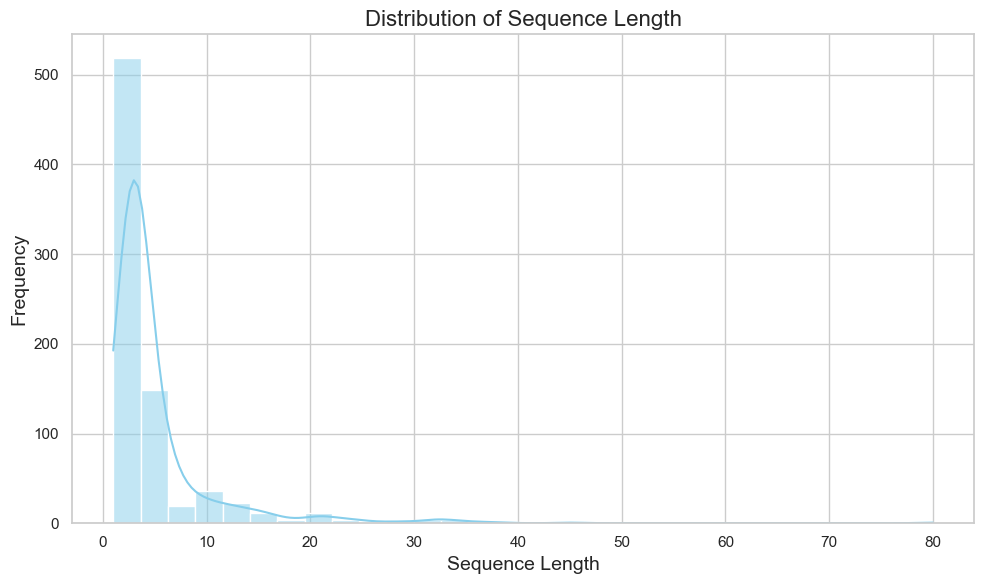

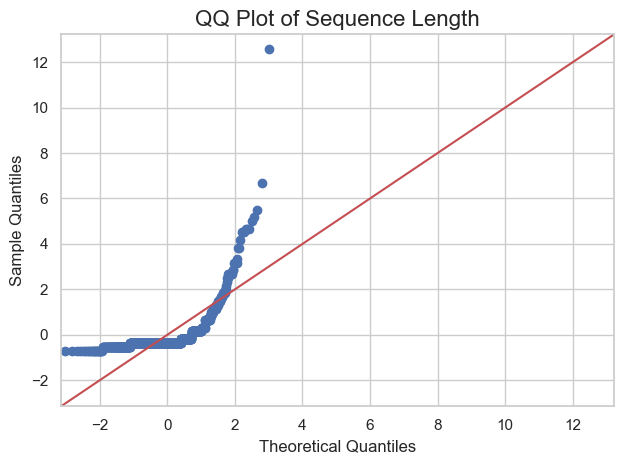

Descriptive Statistics for Sequence Length:
count    791.000000
mean       5.106195
std        5.968173
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max       80.000000
Name: Sequence Length, dtype: float64

Missing values in merged_df:
ID                 0
species            0
type               0
target             0
Sequence           0
Type               0
Sequence Length    0
dtype: int64
DataFrame shape after dropping missing values: (791, 7)


NameError: name 'variance_inflation_factor' is not defined

In [22]:

# -------------------------------
# 6. Inspecting the Distribution of 'Sequence Length'
# -------------------------------

# Histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['Sequence Length'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Sequence Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()

# QQ Plot
sm.qqplot(merged_df['Sequence Length'], line='45', fit=True)
plt.title('QQ Plot of Sequence Length', fontsize=16)
plt.tight_layout()
plt.show()

# Descriptive Statistics
print("Descriptive Statistics for Sequence Length:")
print(merged_df['Sequence Length'].describe())

# -------------------------------
# 7. Generalized Linear Model (GLM) Analysis
# -------------------------------

# a. Handling Missing Values
print("\nMissing values in merged_df:")
print(merged_df.isnull().sum())

# Drop rows with missing values in relevant columns
merged_df_clean = merged_df.dropna(subset=['Sequence Length', 'Type', 'target'])
print(f"DataFrame shape after dropping missing values: {merged_df_clean.shape}")

# b. Encoding Categorical Variables
merged_df_clean['Type'] = merged_df_clean['Type'].astype('category')
merged_df_clean['target'] = merged_df_clean['target'].astype('category')

# c. Checking for Multicollinearity (VIF)
# Create design matrix with dummy variables
X = pd.get_dummies(merged_df_clean[['Type', 'target']], drop_first=True)

# Add constant term
X = sm.add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factor (VIF) for each feature:")
print(vif_data)

# d. Choosing the Model Formula
# Without interaction
formula = 'Q("Sequence Length") ~ Type + target'

# With interaction (optional)
# formula = 'Q("Sequence Length") ~ Type * target'

# e. Fitting the Negative Binomial GLM
print("\nFitting Negative Binomial GLM...")
model_nb = smf.glm(
    formula=formula,
    data=merged_df_clean,
    family=sm.families.NegativeBinomial()
).fit()
print(model_nb.summary())

# If choosing a different family, uncomment below:

# Fitting the Gaussian GLM
# print("\nFitting Gaussian GLM...")
# model_gaussian = smf.glm(
#     formula=formula,
#     data=merged_df_clean,
#     family=sm.families.Gaussian()
# ).fit()
# print(model_gaussian.summary())

# Fitting the Poisson GLM
# print("\nFitting Poisson GLM...")
# model_poisson = smf.glm(
#     formula=formula,
#     data=merged_df_clean,
#     family=sm.families.Poisson()
# ).fit()
# print(model_poisson.summary())

# -------------------------------
# 8. Model Diagnostics
# -------------------------------

# Residuals vs Fitted Values
residuals = model_nb.resid_deviance
fitted = model_nb.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values', fontsize=16)
plt.xlabel('Fitted Values', fontsize=14)
plt.ylabel('Deviance Residuals', fontsize=14)
plt.tight_layout()
plt.show()

# QQ Plot of Residuals
sm.qqplot(residuals, line='45', fit=True)
plt.title('QQ Plot of Deviance Residuals', fontsize=16)
plt.tight_layout()
plt.show()

# Checking Overdispersion
mean_resid_dev = np.mean(residuals)
var_resid_dev = np.var(residuals)
overdispersion = var_resid_dev / mean_resid_dev
print(f"\nOverdispersion Ratio (Variance/Mean): {overdispersion:.2f}")

# -------------------------------
# 9. Model Interpretation
# -------------------------------

# Exponentiated Coefficients for GLM with Log Link
exp_coeff = np.exp(model_nb.params)
print("\nExponentiated Coefficients (Rate Ratios):")
print(exp_coeff)

# -------------------------------
# 10. Visualizing Model Predictions (Optional)
# -------------------------------

# Predicted vs Actual
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_df_clean['Sequence Length'], y=model_nb.fittedvalues, alpha=0.6)
plt.plot([merged_df_clean['Sequence Length'].min(), merged_df_clean['Sequence Length'].max()],
         [merged_df_clean['Sequence Length'].min(), merged_df_clean['Sequence Length'].max()],
         color='red', linestyle='--')
plt.title('Predicted vs Actual Sequence Length', fontsize=16)
plt.xlabel('Actual Sequence Length', fontsize=14)
plt.ylabel('Predicted Sequence Length', fontsize=14)
plt.tight_layout()
plt.show()

# Interaction Plot (if interaction is included)
# plt.figure(figsize=(12, 8))
# interaction_plot(
#     merged_df_clean['Type'],
#     merged_df_clean['target'],
#     merged_df_clean['Sequence Length'],
#     colors=['red', 'blue'],
#     markers=['D', '^'],
#     ms=10
# )
# plt.title('Interaction Plot: Type and Target on Sequence Length', fontsize=16)
# plt.xlabel('Type')
# plt.ylabel('Mean Sequence Length')
# plt.tight_layout()
# plt.show()

Columns before processing: ['ID', 'species', 'type', 'target']
CSV processing successful.
Fasta DataFrame created with 787 records.
Merged DataFrame has 791 records.
Data processing completed successfully.


/var/folders/w7/0t5kmt6s76n4ryth253rlrx00000gn/T/ipykernel_9553/2690828798.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


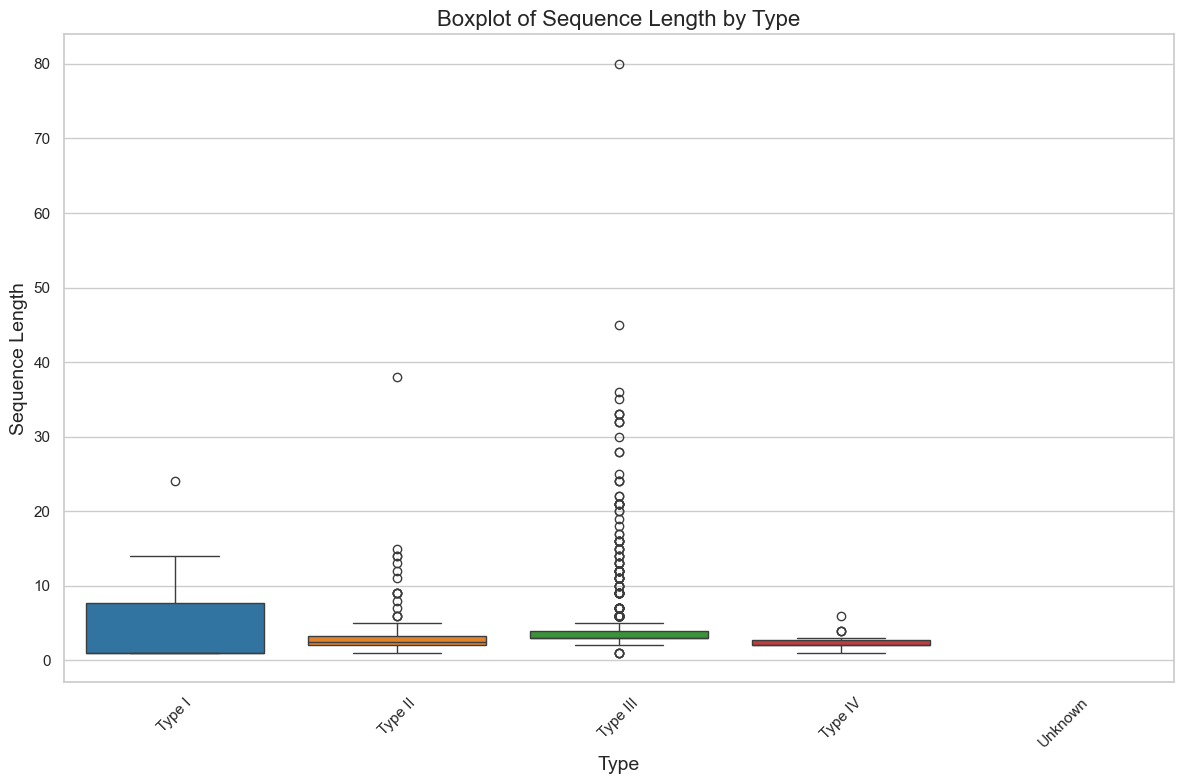

Unique Target categories:
['Non-vertebrate' 'Vertebrate']


/var/folders/w7/0t5kmt6s76n4ryth253rlrx00000gn/T/ipykernel_9553/2690828798.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


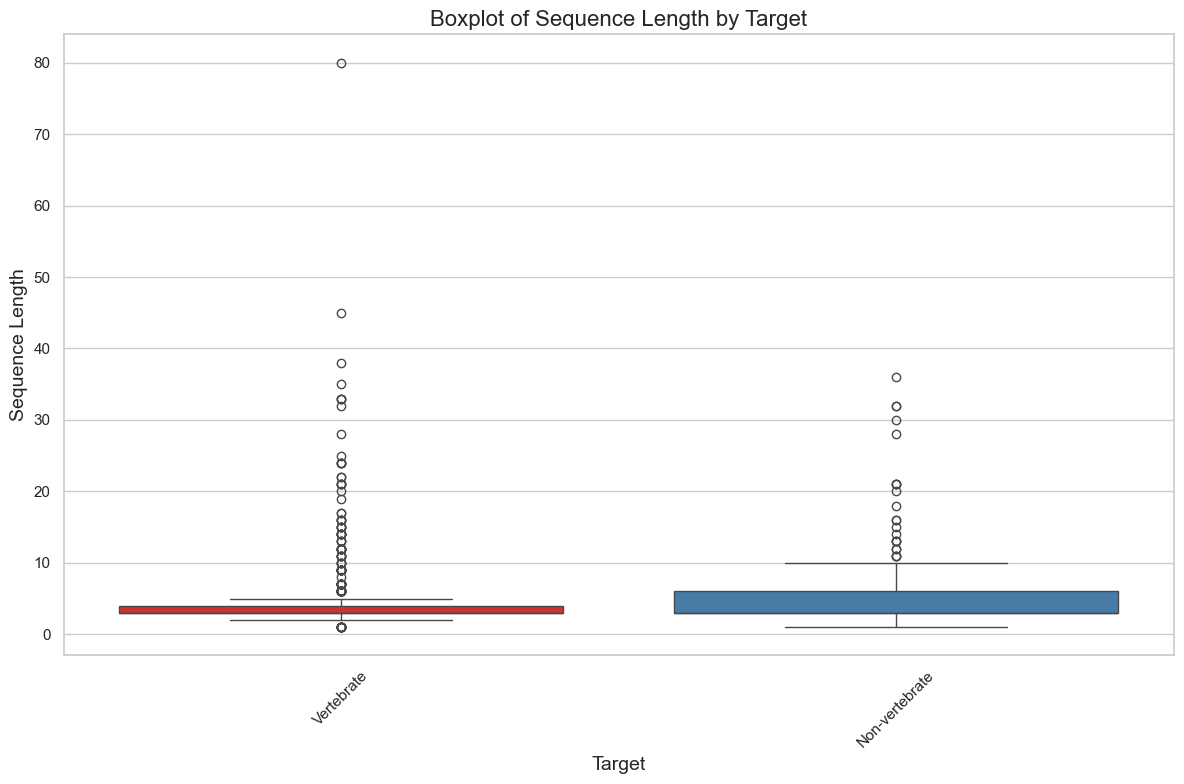

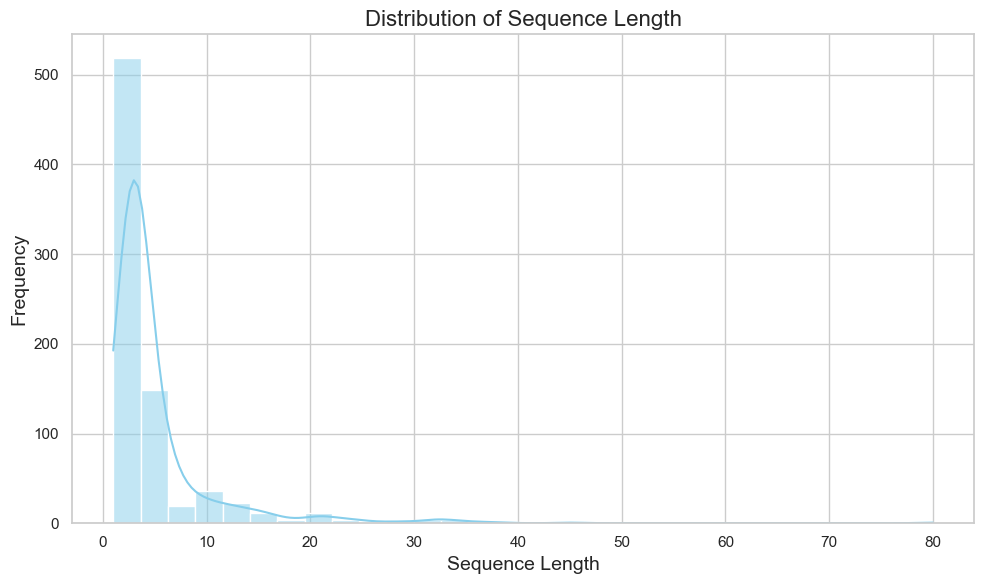

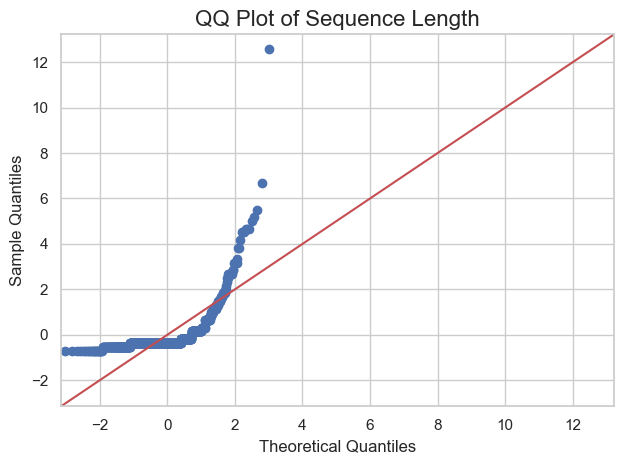

Descriptive Statistics for Sequence Length:
count    791.000000
mean       5.106195
std        5.968173
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max       80.000000
Name: Sequence Length, dtype: float64

Missing values in merged_df:
ID                 0
species            0
type               0
target             0
Sequence           0
Type               0
Sequence Length    0
dtype: int64
DataFrame shape after dropping missing values: (791, 7)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -------------------------------
# 1. Data Processing with Debugging
# -------------------------------

def read_and_process_csv(csv_path):
    try:
        csv_df = pd.read_csv(csv_path, delimiter=";")
        print(f"Columns before processing: {csv_df.columns.tolist()}")
        
        # Check if 'ID' exists
        if 'ID' not in csv_df.columns:
            # Attempt to find the correct column or handle the error
            id_columns = [col for col in csv_df.columns if 'id' in col.lower()]
            if len(id_columns) == 1:
                csv_df.rename(columns={id_columns[0]: 'ID'}, inplace=True)
                print(f"Renamed column '{id_columns[0]}' to 'ID'")
            elif len(id_columns) > 1:
                raise ValueError("Multiple columns containing 'id' found. Please specify which one to use.")
            else:
                raise KeyError("No column containing 'ID' found in the CSV file.")
        
        # Proceed with replacing '.' with '_'
        # Uncomment if needed
        # csv_df['ID'] = csv_df['ID'].astype(str).str.replace('.', '_')
        
        # Rename 'Unnamed: 3' to 'Target' if it exists
        if 'Unnamed: 3' in csv_df.columns:
            csv_df.rename(columns={'Unnamed: 3': 'Target'}, inplace=True)
            print("Renamed 'Unnamed: 3' to 'Target'")
        else:
            print("Warning: 'Unnamed: 3' column not found. 'Target' column not renamed.")
        
        print("CSV processing successful.")
        return csv_df
    
    except FileNotFoundError:
        print(f"Error: The file {csv_path} does not exist.")
    except pd.errors.EmptyDataError:
        print(f"Error: The file {csv_path} is empty.")
    except pd.errors.ParserError:
        print(f"Error: The file {csv_path} is malformed or has parsing issues.")
    except KeyError as e:
        print(f"KeyError: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

def read_fasta_file(fasta_path):
    try:
        fasta_records = []
        for record in SeqIO.parse(fasta_path, "fasta"):
            fasta_records.append({"ID": record.id.replace('.', '_'), "Sequence": str(record.seq)})
        fasta_df = pd.DataFrame(fasta_records)
        print(f"Fasta DataFrame created with {fasta_df.shape[0]} records.")
        return fasta_df
    except FileNotFoundError:
        print(f"Error: The file {fasta_path} does not exist.")
    except Exception as e:
        print(f"An error occurred while reading the FASTA file: {e}")

def merge_dataframes(csv_df, fasta_df):
    try:
        merged_df = pd.merge(csv_df, fasta_df, on="ID", how="inner")
        print(f"Merged DataFrame has {merged_df.shape[0]} records.")
        return merged_df
    except KeyError as e:
        print(f"Merge KeyError: {e}")
    except Exception as e:
        print(f"An error occurred during merging: {e}")

# File paths
csv_path = 'label.csv'
fasta_path = 'nonredundant_seq_0.3.fasta'

# Read and process CSV
csv_df = read_and_process_csv(csv_path)
if csv_df is None:
    raise SystemExit("CSV processing failed. Exiting.")

# Read FASTA file
fasta_df = read_fasta_file(fasta_path)
if fasta_df is None:
    raise SystemExit("FASTA processing failed. Exiting.")

# Merge DataFrames
merged_df = merge_dataframes(csv_df, fasta_df)
if merged_df is None:
    raise SystemExit("Merging DataFrames failed. Exiting.")

# Type Mapping
type_mapping = {
    'TypeIII': 'Type III',
    'TypeIII_controlToxin': 'Type III',
    'TypeII_PFT_bacteria': 'Type II',
    'Type_I': 'Type I',
    'Type_II': 'Type II',
    'Type_III': 'Type III',
    'Type_IV': 'Type IV',
    'Unknown': 'Unknown'
}

# Check if 'type' column exists
if 'type' not in merged_df.columns:
    print("Error: 'type' column not found in merged DataFrame.")
    print(f"Available columns: {merged_df.columns.tolist()}")
    raise SystemExit("Required column 'type' is missing.")

# Map Types
merged_df['Type'] = merged_df['type'].replace(type_mapping)

# Calculate Sequence Length
merged_df['Sequence Length'] = merged_df['Sequence'].apply(len)

print("Data processing completed successfully.")

# -------------------------------
# 2. Define Order and Palette for 'Type'
# -------------------------------

# Define the desired order
type_order = ['Type I', 'Type II', 'Type III', 'Type IV', 'Unknown']

# Define a custom color palette
type_palette = {
    'Type I': '#1f77b4',       # Blue
    'Type II': '#ff7f0e',      # Orange
    'Type III': '#2ca02c',     # Green
    'Type IV': '#d62728',      # Red
    'Unknown': '#9467bd'       # Purple
}

# Ensure that the 'Type' column is a categorical type with the specified order
merged_df['Type'] = pd.Categorical(merged_df['Type'], categories=type_order, ordered=True)

# -------------------------------
# 3. Create the Boxplot for 'Type'
# -------------------------------

plt.figure(figsize=(12, 8))
sns.boxplot(
    x='Type',
    y='Sequence Length',
    data=merged_df,
    palette=type_palette,
    order=type_order
)
plt.title('Boxplot of Sequence Length by Type', fontsize=16)
plt.xlabel('Type', fontsize=14)
plt.ylabel('Sequence Length', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Define Order and Palette for 'Target'
# -------------------------------

# Check unique values in 'Target'
print("Unique Target categories:")
print(merged_df['target'].unique())

# Define the desired order based on unique values
# Replace the list below with the actual categories in your 'Target' column
target_order = ['Vertebrate', 'Non-vertebrate']

# Define a custom color palette for 'Target'
target_palette = {
    'Vertebrate': '#e41a1c',      # Red
    'Non-vertebrate': '#377eb8'   # Blue
}

# Ensure that the 'Target' column is a categorical type with the specified order
merged_df['target'] = pd.Categorical(merged_df['target'], categories=target_order, ordered=True)

# -------------------------------
# 5. Create the Boxplot for 'Target'
# -------------------------------

plt.figure(figsize=(12, 8))
sns.boxplot(
    x='target',
    y='Sequence Length',
    data=merged_df,
    palette=target_palette,
    order=target_order
)
plt.title('Boxplot of Sequence Length by Target', fontsize=16)
plt.xlabel('Target', fontsize=14)
plt.ylabel('Sequence Length', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 6. Inspecting the Distribution of 'Sequence Length'
# -------------------------------

# Histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['Sequence Length'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Sequence Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()

# QQ Plot
sm.qqplot(merged_df['Sequence Length'], line='45', fit=True)
plt.title('QQ Plot of Sequence Length', fontsize=16)
plt.tight_layout()
plt.show()

# Descriptive Statistics
print("Descriptive Statistics for Sequence Length:")
print(merged_df['Sequence Length'].describe())

# -------------------------------
# 7. Generalized Linear Model (GLM) Analysis
# -------------------------------

# a. Handling Missing Values
print("\nMissing values in merged_df:")
print(merged_df.isnull().sum())

# Drop rows with missing values in relevant columns
merged_df_clean = merged_df.dropna(subset=['Sequence Length', 'Type', 'target'])
print(f"DataFrame shape after dropping missing values: {merged_df_clean.shape}")

# b. Encoding Categorical Variables
merged_df_clean['Type'] = merged_df_clean['Type'].astype('category')
merged_df_clean['target'] = merged_df_clean['target'].astype('category')

# c. Checking for Multicollinearity (VIF)
# Create design matrix with dummy variables
X = pd.get_dummies(merged_df_clean[['Type', 'target']], drop_first=True)

# Add constant term
X = sm.add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factor (VIF) for each feature:")
print(vif_data)

# d. Choosing the Model Formula
# Without interaction
formula = 'Q("Sequence Length") ~ Type + target'

# With interaction (optional)
# formula = 'Q("Sequence Length") ~ Type * target'

# e. Fitting the Negative Binomial GLM
print("\nFitting Negative Binomial GLM...")
model_nb = smf.glm(
    formula=formula,
    data=merged_df_clean,
    family=sm.families.NegativeBinomial()
).fit()
print(model_nb.summary())

# If choosing a different family, uncomment below:

# Fitting the Gaussian GLM
# print("\nFitting Gaussian GLM...")
# model_gaussian = smf.glm(
#     formula=formula,
#     data=merged_df_clean,
#     family=sm.families.Gaussian()
# ).fit()
# print(model_gaussian.summary())

# Fitting the Poisson GLM
# print("\nFitting Poisson GLM...")
# model_poisson = smf.glm(
#     formula=formula,
#     data=merged_df_clean,
#     family=sm.families.Poisson()
# ).fit()
# print(model_poisson.summary())

# -------------------------------
# 8. Model Diagnostics
# -------------------------------

# Residuals vs Fitted Values
residuals = model_nb.resid_deviance
fitted = model_nb.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values', fontsize=16)
plt.xlabel('Fitted Values', fontsize=14)
plt.ylabel('Deviance Residuals', fontsize=14)
plt.tight_layout()
plt.show()

# QQ Plot of Residuals
sm.qqplot(residuals, line='45', fit=True)
plt.title('QQ Plot of Deviance Residuals', fontsize=16)
plt.tight_layout()
plt.show()

# Checking Overdispersion
mean_resid_dev = np.mean(residuals)
var_resid_dev = np.var(residuals)
overdispersion = var_resid_dev / mean_resid_dev
print(f"\nOverdispersion Ratio (Variance/Mean): {overdispersion:.2f}")

# -------------------------------
# 9. Model Interpretation
# -------------------------------

# Exponentiated Coefficients for GLM with Log Link
exp_coeff = np.exp(model_nb.params)
print("\nExponentiated Coefficients (Rate Ratios):")
print(exp_coeff)

# -------------------------------
# 10. Visualizing Model Predictions (Optional)
# -------------------------------

# Predicted vs Actual
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_df_clean['Sequence Length'], y=model_nb.fittedvalues, alpha=0.6)
plt.plot([merged_df_clean['Sequence Length'].min(), merged_df_clean['Sequence Length'].max()],
         [merged_df_clean['Sequence Length'].min(), merged_df_clean['Sequence Length'].max()],
         color='red', linestyle='--')
plt.title('Predicted vs Actual Sequence Length', fontsize=16)
plt.xlabel('Actual Sequence Length', fontsize=14)
plt.ylabel('Predicted Sequence Length', fontsize=14)
plt.tight_layout()
plt.show()

# Interaction Plot (if interaction is included)
# plt.figure(figsize=(12, 8))
# interaction_plot(
#     merged_df_clean['Type'],
#     merged_df_clean['target'],
#     merged_df_clean['Sequence Length'],
#     colors=['red', 'blue'],
#     markers=['D', '^'],
#     ms=10
# )
# plt.title('Interaction Plot: Type and Target on Sequence Length', fontsize=16)
# plt.xlabel('Type')
# plt.ylabel('Mean Sequence Length')
# plt.tight_layout()
# plt.show()
